In [1]:
"""
openmc_two_slab_verification.py
================================
OpenMC verification tallies for the custom delta-tracking two-slab simulation.

Tallies implemented
--------------------
  1. Flux (TLE)            — per cell × energy group
  2. Reaction rates        — absorption, scatter, fission per cell × energy group
  3. Current               — net, forward, backward at x=2 interface + leakage surfaces
  4. Energy spectrum       — fine log-spaced bins to check scattering kernel
  5. Leakage fraction      — surface current at vacuum boundaries
  6. Flux shape ratio      — slab1 vs slab2 per unit volume

All results printed with units clearly labelled and compared to
what your custom code should produce.
"""

import openmc
import openmc.mgxs
import numpy as np

# ============================================================================
# Cross section library
# ============================================================================
# openmc.config['cross_sections'] = '/path/to/cross_sections.xml'

# ============================================================================
# Materials
# ============================================================================
rho_U       = 19.1  # g/cm³
N_U235_frac = 0.05
N_U238_frac = 1.0

mat1 = openmc.Material(name="U8 @ 293K")
mat1.set_density('g/cm3', rho_U)
 

mat1.add_nuclide('U238', N_U238_frac, percent_type='ao')
mat1.temperature = 293.6
mat1.isotropic = ['U238']
# Isotropic scattering in lab frame — matches custom code (isotropic CM sampling)


mat2 = openmc.Material(name="U @ 2000K")
mat2.set_density('g/cm3', rho_U)

mat2.add_nuclide('U238', N_U238_frac, percent_type='ao')
#mat2.add_nuclide('U235', N_U235_frac, percent_type='ao')
mat2.temperature = 2000.0
mat2.isotropic = ['U238']

materials = openmc.Materials([mat1, mat2])
materials.export_to_xml()







# ============================================================================
# Geometry
# ============================================================================
x0 = openmc.XPlane(x0=0.0,  boundary_type='vacuum')
x1 = openmc.XPlane(x0=2.0)
x2 = openmc.XPlane(x0=15.0, boundary_type='vacuum')

y0 = openmc.YPlane(y0=-1000.0, boundary_type='reflective')
y1 = openmc.YPlane(y0=1000.0, boundary_type='reflective')
z0 = openmc.ZPlane(z0=-1000.0, boundary_type='reflective')
z1 = openmc.ZPlane(z0=1000.0, boundary_type='reflective')

transverse = +y0 & -y1 & +z0 & -z1

cell1 = openmc.Cell(cell_id= 15 ,name='slab1', fill=mat1, region=+x0 & -x1 & transverse)
cell2 = openmc.Cell(cell_id= 16 ,name='slab2', fill=mat2, region=+x1 & -x2 & transverse)

geometry = openmc.Geometry(openmc.Universe(cells=[cell1, cell2]))
geometry.export_to_xml()





# ============================================================================
# Settings
# ============================================================================
N_PARTICLES = 50000
N_BATCHES   = 20    # 100,000 total — proper variance estimate

settings = openmc.Settings()
settings.run_mode  = 'fixed source'
settings.particles = N_PARTICLES
settings.batches   = N_BATCHES





settings.temperature = {
    'multipole' : True,
    'method'    : 'nearest',
    'tolerance' : 3000.0,
}

settings.cutoff = {'energy': 70.0}
settings.create_fission_neutrons = False
# Note: settings.legendre_order does not exist in OpenMC for continuous-energy mode.
# Isotropic CM scattering is enforced per-material via material.isotropic.
# This is set on mat1 and mat2 above.

source = openmc.IndependentSource()
source.space    = openmc.stats.Point((1e-6, 0.0, 0.0))
source.angle    = openmc.stats.Monodirectional(reference_uvw=(1., 0., 0.))
source.energy   = openmc.stats.Discrete([500.0], [1.0])
source.particle = 'neutron'
settings.source = source

settings.export_to_xml()


# ============================================================================
# Multi-Group Cross Sections
# ============================================================================
energy_groups = openmc.mgxs.EnergyGroups(group_edges=[10.0, 600.0])

mgxs_library = openmc.mgxs.Library(geometry)
mgxs_library.energy_groups = energy_groups
mgxs_library.domain_type = 'cell'
mgxs_library.domains = [cell1, cell2]  
mgxs_library.by_nuclide = False

mgxs_library.mgxs_types = [
    'total',
    'absorption',
    'scatter matrix',
    'nu-scatter matrix',
    'transport'
    
]

mgxs_library.build_library()

tallies = openmc.Tallies()
mgxs_library.add_to_tallies_file(tallies, merge=True)




# ============================================================================
# Filters (shared across tallies)
# ============================================================================
energy_bins      = [10, 50, 100, 600] #[10.0, 50.0, 500.0, 1e4, 1e6, 2e7]          # coarse — matches custom code
energy_bins_fine = [10, 600] #np.logspace(np.log10(10.0), 2.0, 60).tolist() # fine log-spaced 10–100 eV

cell_filter        = openmc.CellFilter([cell1, cell2])
energy_filter      = openmc.EnergyFilter(energy_bins)
energy_filter_fine = openmc.EnergyFilter(energy_bins_fine)

# surface filters
surf_interface  = openmc.SurfaceFilter([x1])    # x=2 interface between slabs
surf_left       = openmc.SurfaceFilter([x0])    # x=0 left vacuum boundary
surf_right      = openmc.SurfaceFilter([x2])    # x=15 right vacuum boundary
surf_leakage    = openmc.SurfaceFilter([x0, x2])# both vacuum boundaries

# ── tally 1 : flux ────────────────────────────────────────────────────────────
t_flux = openmc.Tally(name='flux')
t_flux.filters = [cell_filter, energy_filter]
t_flux.scores  = ['flux']

# ── tally 2 : reaction rates ─────────────────────────────────────────────────
t_rxn = openmc.Tally(name='reaction_rates')
t_rxn.filters = [cell_filter, energy_filter]
t_rxn.scores  = ['absorption', 'scatter', 'fission', 'total']

# ── tally 3a : net current at x=2 interface ──────────────────────────────────
# Net current = forward - backward, scored when any particle crosses x=2
t_current_net = openmc.Tally(name='current_net_interface')
t_current_net.filters = [surf_interface]
t_current_net.scores  = ['current']

# ── tally 3b : partial currents (forward / backward) at x=2 ─────────────────
# Forward  : particle crosses x=2 coming FROM cell1 (slab1 → slab2, +x)
# Backward : particle crosses x=2 coming FROM cell2 (slab2 → slab1, -x)
# CellFromFilter selects particles based on which cell they just left.

cellfrom_slab1 = openmc.CellFromFilter(cell1)   # particle was in slab1
cellfrom_slab2 = openmc.CellFromFilter(cell2)   # particle was in slab2

t_current_fwd = openmc.Tally(name='current_fwd_interface')
t_current_fwd.filters = [surf_interface, cellfrom_slab1]
t_current_fwd.scores  = ['current']

t_current_bwd = openmc.Tally(name='current_bwd_interface')
t_current_bwd.filters = [surf_interface, cellfrom_slab2]
t_current_bwd.scores  = ['current']

# ── tally 4 : energy spectrum (fine bins) ────────────────────────────────────
t_spectrum = openmc.Tally(name='spectrum')
t_spectrum.filters = [cell_filter, energy_filter_fine]
t_spectrum.scores  = ['flux']

# ── tally 5 : leakage at vacuum boundaries ───────────────────────────────────
t_leak_left = openmc.Tally(name='leakage_left')
t_leak_left.filters = [surf_left]
t_leak_left.scores  = ['current']

t_leak_right = openmc.Tally(name='leakage_right')
t_leak_right.filters = [surf_right]
t_leak_right.scores  = ['current']

# ── tally 6 : scattering angle distribution (MuFilter) ──────────────────────
# MUST use analog estimator — MuFilter requires post-collision state.
# 10 equal bins covering mu = cos(theta) in [-1, 1].
# mu = -1 : backward scatter (180°)
# mu =  0 : sideways scatter (90°)
# mu = +1 : forward scatter  (0°)
# For isotropic CM scattering on heavy nuclei (U238), the lab-frame
# distribution is strongly forward-peaked — most mu_lab values near +1.
N_MU_BINS  = 10
mu_filter  = openmc.MuFilter(N_MU_BINS)   # 10 equal bins on [-1, 1]

t_mu = openmc.Tally(name='scattering_angle_lab')
t_mu.filters   = [cell_filter, mu_filter]
t_mu.scores    = ['scatter']
t_mu.estimator = 'analog'   # mandatory for MuFilter

tallies += [
    t_flux,
    t_rxn,
    t_current_net,
    t_current_fwd,
    t_current_bwd,
    t_spectrum,
    t_leak_left,
    t_leak_right,
    t_mu,
]
tallies.export_to_xml()

# ============================================================================
# Run
# ============================================================================

openmc.run()





/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=42.
  warn(msg, IDWarning)
/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=2.
  warn(msg, IDWarning)
/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=7.
  warn(msg, IDWarning)
/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=8.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################


  TALLY 1 — FLUX (track-length estimator)
  Units: cm · source-neutron⁻¹
  Region                                 10–50 eV       50–100 eV      100–600 eV
--------------------------------------------------------------------------------
  slab1  (0–2 cm,   293.6 K)      0.000e+00 ±0.0e+000.000e+00 ±0.0e+004.558e+00 ±4.4e-03
  slab2  (2–15 cm, 293.0 K)       0.000e+00 ±0.0e+000.000e+00 ±0.0e+008.672e+00 ±1.5e-02

  TALLY 1b — FLUX DENSITY (volume-normalised)
  Units: cm⁻² · source-neutron⁻¹
  Region                                 10–50 eV       50–100 eV      100–600 eV
--------------------------------------------------------------------------------
  slab1  (0–2 cm,   293.6 K)      0.000e+00 ±0.0e+000.000e+00 ±0.0e+002.279e+00 ±2.2e-03
  slab2  (2–15 cm, 293.0 K)       0.000e+00 ±0.0e+000.000e+00 ±0.0e+006.671e-01 ±1.1e-03

  FLUX SHAPE RATIO  slab1/slab2 (per unit volume):
                10–50 eV  ratio = nan   (custom code should give ~same value)
               50–100 eV  ratio = 

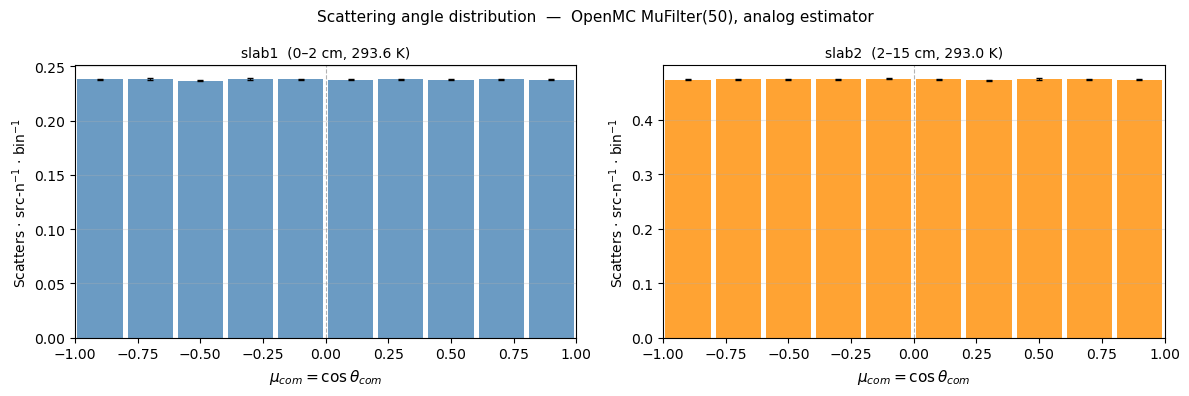


  SUMMARY — VALUES TO COMPARE WITH CUSTOM CODE
  Quantity                        slab1          slab2
  ────────────────────────────────────────────────────────
  Flux [cm·src-n⁻¹]           4.5577e+00     8.6720e+00
  Flux density [cm⁻²·src-n⁻¹]  2.2789e+00     6.6708e-01
  Flux ratio (slab1/slab2)        3.4162   (per unit volume)
  Leakage fraction                0.5216
  Fwd/Bwd current ratio          -2.0400


In [2]:
# ============================================================================
# Post-process
# ============================================================================
sp         = openmc.StatePoint(f'statepoint.{N_BATCHES}.h5')
volumes    = np.array([2.0, 13.0])   # cm³
cell_names = ['slab1  (0–2 cm,   293.6 K)', 'slab2  (2–15 cm, 293.0 K)']
n_cells    = 2
n_groups   = len(energy_bins) - 1
e_labels   = [f"{energy_bins[i]:.0f}–{energy_bins[i+1]:.0f} eV"
              for i in range(n_groups)]

def print_table(title, units, data_mean, data_std, row_names, col_names, col_width=16):
    w = max(col_width, max(len(c) for c in col_names) + 2)
    bar = "=" * (32 + w * len(col_names))
    print(f"\n{bar}")
    print(f"  {title}")
    print(f"  Units: {units}")
    print(bar)
    print(f"  {'Region':<30}", "".join(f"{c:>{w}}" for c in col_names))
    print("-" * (32 + w * len(col_names)))
    for ri, name in enumerate(row_names):
        vals = "".join(
            f"{data_mean[ri, ei]:>{w-7}.3e} ±{data_std[ri, ei]:.1e}"
            for ei in range(len(col_names))
        )
        print(f"  {name:<30}  {vals}")
    print(bar)

# ── 1. Flux ──────────────────────────────────────────────────────────────────
t = sp.get_tally(name='flux')
flux_mean = t.get_values(scores=['flux'], value='mean'   ).reshape(n_cells, n_groups)
flux_std  = t.get_values(scores=['flux'], value='std_dev').reshape(n_cells, n_groups)

print_table(
    'TALLY 1 — FLUX (track-length estimator)',
    'cm · source-neutron⁻¹',
    flux_mean, flux_std, cell_names, e_labels
)

# Also print volume-normalised flux density
flux_dens_mean = flux_mean / volumes[:, np.newaxis]
flux_dens_std  = flux_std  / volumes[:, np.newaxis]
print_table(
    'TALLY 1b — FLUX DENSITY (volume-normalised)',
    'cm⁻² · source-neutron⁻¹',
    flux_dens_mean, flux_dens_std, cell_names, e_labels
)

# ── 1c. Flux shape ratio ─────────────────────────────────────────────────────
print("\n  FLUX SHAPE RATIO  slab1/slab2 (per unit volume):")
for ei, lab in enumerate(e_labels):
    r  = flux_dens_mean[0, ei] / flux_dens_mean[1, ei] if flux_dens_mean[1, ei] > 0 else float('nan')
    print(f"    {lab:>20}  ratio = {r:.4f}   "
          f"(custom code should give ~same value)")

# ── 2. Reaction rates ────────────────────────────────────────────────────────
t = sp.get_tally(name='reaction_rates')
for score in ['absorption', 'scatter', 'fission', 'total']:
    rxn_mean = t.get_values(scores=[score], value='mean'   ).reshape(n_cells, n_groups)
    rxn_std  = t.get_values(scores=[score], value='std_dev').reshape(n_cells, n_groups)
    print_table(
        f'TALLY 2 — {score.upper()} RATE',
        'reactions · source-neutron⁻¹',
        rxn_mean, rxn_std, cell_names, e_labels
    )

# ── 2b. Self-consistency check: absorption_rate = Σ_a × flux × V ────────────
abs_mean  = sp.get_tally(name='reaction_rates').get_values(
    scores=['absorption'], value='mean').reshape(n_cells, n_groups)
scat_mean = sp.get_tally(name='reaction_rates').get_values(
    scores=['scatter'], value='mean').reshape(n_cells, n_groups)

print("\n  SELF-CONSISTENCY CHECK:")
print("  absorption + scatter should ≈ total reaction rate")
for ri, name in enumerate(cell_names):
    for ei, lab in enumerate(e_labels):
        tot_rxn = sp.get_tally(name='reaction_rates').get_values(
            scores=['total'], value='mean').reshape(n_cells, n_groups)
        implied = abs_mean[ri, ei] + scat_mean[ri, ei]
        actual  = tot_rxn[ri, ei]
        diff    = abs(implied - actual) / actual * 100 if actual > 0 else 0
        if implied > 0:
            print(f"    {name[:20]}  {lab:>18}  "
                  f"abs+scat={implied:.4e}  total={actual:.4e}  diff={diff:.2f}%")

# ── 3. Current at x=2 interface ──────────────────────────────────────────────
t_fwd = sp.get_tally(name='current_fwd_interface')
t_bwd = sp.get_tally(name='current_bwd_interface')

fwd = float(t_fwd.get_values(scores=['current'], value='mean').flat[0])
bwd = float(t_bwd.get_values(scores=['current'], value='mean').flat[0])
fwd_std = float(t_fwd.get_values(scores=['current'], value='std_dev').flat[0])
bwd_std = float(t_bwd.get_values(scores=['current'], value='std_dev').flat[0])

print(f"""
{"="*60}
  TALLY 3 — CURRENT AT x=2 INTERFACE
  Units: particles · source-neutron⁻¹
{"="*60}
  Forward  (+x, slab1→slab2) : {fwd:.4e} ± {fwd_std:.2e}
  Backward (-x, slab2→slab1) : {bwd:.4e} ± {bwd_std:.2e}
  Net current (fwd + bwd)    : {fwd + bwd:.4e}
  Forward/Backward ratio     : {fwd/bwd:.4f}  (>1 means net rightward flow, expected)
{"="*60}

{"="*60}""")

# ── 4. Energy spectrum ───────────────────────────────────────────────────────
t = sp.get_tally(name='spectrum')
spec_mean = t.get_values(scores=['flux'], value='mean').reshape(n_cells, len(energy_bins_fine) - 1)
spec_std  = t.get_values(scores=['flux'], value='std_dev').reshape(n_cells, len(energy_bins_fine) - 1)

print(f"""
{"="*60}
  TALLY 4 — ENERGY SPECTRUM (fine bins, 10–100 eV)
  Units: cm · source-neutron⁻¹ per energy bin
{"="*60}
  Printing bins with nonzero flux:""")

fine_labels = [f"{energy_bins_fine[i]:.2f}–{energy_bins_fine[i+1]:.2f} eV"
               for i in range(len(energy_bins_fine) - 1)]
for ei, lab in enumerate(fine_labels):
    s1 = spec_mean[0, ei]
    s2 = spec_mean[1, ei]
    if s1 + s2 > 0:
        print(f"    {lab:>22}  slab1={s1:.3e}  slab2={s2:.3e}")

print(f"""
{"="*60}""")

# ── 5. Leakage ───────────────────────────────────────────────────────────────
t_left  = sp.get_tally(name='leakage_left')
t_right = sp.get_tally(name='leakage_right')

leak_left  = float(t_left.get_values( scores=['current'], value='mean').flat[0])
leak_right = float(t_right.get_values(scores=['current'], value='mean').flat[0])
leak_left_std  = float(t_left.get_values( scores=['current'], value='std_dev').flat[0])
leak_right_std = float(t_right.get_values(scores=['current'], value='std_dev').flat[0])
leak_total = -leak_left + leak_right

print(f"""
{"="*60}
  TALLY 5 — LEAKAGE FRACTION
{"="*60}
  Left  leakage (x=0,  backward) : {leak_left:.4e} ± {leak_left_std:.2e}
  Right leakage (x=15, forward)  : {leak_right:.4e} ± {leak_right_std:.2e}
  Total leakage fraction         : {leak_total:.4f}  ({leak_total*100:.2f}%)


{"="*60}""")

# ── 6. Scattering angle distribution ─────────────────────────────────────────
t_mu_sp = sp.get_tally(name='scattering_angle_lab')
mu_mean = t_mu_sp.get_values(scores=['scatter'], value='mean'   ).reshape(n_cells, N_MU_BINS)
mu_std  = t_mu_sp.get_values(scores=['scatter'], value='std_dev').reshape(n_cells, N_MU_BINS)



mu_edges   = np.linspace(-1., 1., N_MU_BINS + 1)
mu_centers = 0.5 * (mu_edges[:-1] + mu_edges[1:])
mu_width   = mu_edges[1] - mu_edges[0]

print(f"""
{"="*70}
  TALLY 6 — SCATTERING ANGLE DISTRIBUTION
  Score : scatter  (analog estimator)
  Units : scatters · source-neutron⁻¹ per mu bin  (bin width = {mu_width:.2f})
  mu    : cos(theta_com)   -1=backward   0=sideways   +1=forward
{"="*70}
  {"mu bin":>10}  {"slab1 (293K)":>22}  {"slab2 (293K)":>22}
  {"-"*66}""")


# matplotlib plot (saved to file if available)
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    titles = ['slab1  (0–2 cm, 293.6 K)', 'slab2  (2–15 cm, 293.0 K)']
    colors = ['steelblue', 'darkorange']
    for ax, ri, title, color in zip(axes, range(n_cells), titles, colors):
        ax.bar(mu_centers, mu_mean[ri], width=mu_width * 0.9,
               color=color, alpha=0.8, label=title,
               yerr=mu_std[ri], capsize=2, error_kw={'linewidth': 0.7})
        ax.set_xlabel(r'$\mu_{com} = \cos\theta_{com}$', fontsize=11)
        ax.set_ylabel(r'Scatters · src-n$^{-1}$ · bin$^{-1}$', fontsize=10)
        ax.set_title(title, fontsize=10)
        ax.set_xlim(-1, 1)
        ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.grid(axis='y', alpha=0.3)
    fig.suptitle('Scattering angle distribution  —  OpenMC MuFilter(50), analog estimator',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig('scattering_angle_distribution.png', dpi=150, bbox_inches='tight')
    print("  Plot saved → scattering_angle_distribution.png")
    plt.show()
except ImportError:
    print("  (matplotlib not available — install to get the plot)")

# ── 7. Summary comparison table ──────────────────────────────────────────────
print(f"""
{"="*60}
  SUMMARY — VALUES TO COMPARE WITH CUSTOM CODE
{"="*60}
  Quantity                        slab1          slab2
  {"─"*56}
  Flux [cm·src-n⁻¹]         {flux_mean[0].sum():>12.4e}   {flux_mean[1].sum():>12.4e}
  Flux density [cm⁻²·src-n⁻¹]{flux_dens_mean[0].sum():>12.4e}   {flux_dens_mean[1].sum():>12.4e}
  Flux ratio (slab1/slab2)  {flux_dens_mean[0].sum()/flux_dens_mean[1].sum():>12.4f}   (per unit volume)
  Leakage fraction          {leak_total:>12.4f}
  Fwd/Bwd current ratio     {fwd/bwd:>12.4f}
{"="*60}""")

In [67]:
sp = openmc.StatePoint('statepoint.20.h5')
t = sp.get_tally(name='reaction_rates')   # name you gave it in the OpenMC script
df_one_group = t.get_pandas_dataframe()
print(df_one_group)

t_flux = sp.get_tally(name='flux')
df_flux = t_flux.get_pandas_dataframe()
print(df_flux)

   cell  energy low [eV]  energy high [eV] nuclide       score     mean  \
0    15         1.00e+01          6.00e+02   total  absorption 9.25e-02   
1    15         1.00e+01          6.00e+02   total     scatter 2.39e+00   
2    15         1.00e+01          6.00e+02   total     fission 1.14e-06   
3    15         1.00e+01          6.00e+02   total       total 2.48e+00   
4    16         1.00e+01          6.00e+02   total  absorption 3.85e-01   
5    16         1.00e+01          6.00e+02   total     scatter 4.79e+00   
6    16         1.00e+01          6.00e+02   total     fission 6.02e-06   
7    16         1.00e+01          6.00e+02   total       total 5.18e+00   

   std. dev.  
0   2.21e-04  
1   2.39e-03  
2   6.48e-09  
3   2.44e-03  
4   6.51e-04  
5   8.38e-03  
6   1.45e-08  
7   8.89e-03  
   cell  energy low [eV]  energy high [eV] nuclide score     mean  std. dev.
0    15         1.00e+01          6.00e+02   total  flux 4.57e+00   4.45e-03
1    16         1.00e+01          6

In [5]:
mgxs_library.load_from_statepoint(sp)

# ========================================================================
# Export MGXS to HDF5 for multi-group run
# ========================================================================
mg_lib = mgxs_library.create_mg_library()
mg_lib.export_to_hdf5('mgxs.h5')

print("\nMGXS library exported → mgxs.h5")


MGXS library exported → mgxs.h5
